In [1]:
#installing core libraries
!pip install pandas numpy matplotlib seaborn sqlalchemy pymysql

## Data importatiom

In [10]:
#getting the data into Python
import pandas as pd

df = pd.read_csv("superstore_sales.csv", encoding="latin1")#In Python and pandas, text files are assumed to be UTF‑8 by default  # or encoding="latin1" tells pandas to decode the file using the Latin‑1 (ISO‑8859‑1) character set instead of UTF‑8 in read.csv
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data inspection

In [14]:
df.shape #size of the dataframe(number of rows and columns in the dataframe)


(9994, 21)

In [13]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [16]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Column adjustment

In [17]:
df.columns = df.columns.str.lower().str.replace(" ", "_")#converys column names to lower cases making the sql easier
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Date conversions

In [19]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Checking for Missing Values

In [20]:
df.isnull().sum()

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub-category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64

## Saving the cleaned data


In [21]:
df.to_csv("../data/clean_superstore_sales.csv", index=False)

## Loading the Cleaned Data into a SQL Database

In [22]:
import sqlite3

# creating an in-memory database
conn = sqlite3.connect(':memory:')

# load dataframe into SQL
df.to_sql('sales', conn, index=False, if_exists='replace')

9994

## Testing the SQL setup

In [25]:
query = """
SELECT *
FROM sales
LIMIT 5
"""

pd.read_sql(query, conn)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12 00:00:00,2016-06-16 00:00:00,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Calculating Core Business KPIs

In [27]:
#total sales
query = """
SELECT SUM(sales) AS total_sales
FROM sales
"""

pd.read_sql(query, conn)

,total_sales
0,2.297201e+06


In [28]:
#total profit
query = """
SELECT SUM(profit) AS total_profit
FROM sales
"""

pd.read_sql(query, conn)

,total_profit
0,286397.0217


In [29]:
#total orders
query = """
SELECT COUNT(DISTINCT order_id) AS total_orders
FROM sales
"""

pd.read_sql(query, conn)

,total_orders
0,5009


In [30]:
#average discount
query = """
SELECT AVG(discount) AS avg_discount
FROM sales
"""

pd.read_sql(query, conn)

,avg_discount
0,0.156203


**Querying Regional Sales Performance**

In [31]:
query = """
SELECT region,
       SUM(sales) AS total_sales,
       SUM(profit) AS total_profit
FROM sales
GROUP BY region
ORDER BY total_sales DESC
"""

pd.read_sql(query, conn)


,region,total_sales,total_profit
0,West,725457.8245,108418.4489
1,East,678781.2400,91522.7800
2,Central,501239.8908,39706.3625
3,South,391721.9050,46749.4303


**Querying category performance**

In [32]:
query = """
SELECT category,
       SUM(sales) AS total_sales,
       SUM(profit) AS total_profit
FROM sales
GROUP BY category
ORDER BY total_profit DESC
"""

pd.read_sql(query, conn)

,category,total_sales,total_profit
0,Technology,836154.0330,145454.9481
1,Office Supplies,719047.0320,122490.8008
2,Furniture,741999.7953,18451.2728


**Querying high-value customers (top 10)**

In [33]:
query = """
SELECT customer_name,
       SUM(sales) AS total_sales
FROM sales
GROUP BY customer_name
ORDER BY total_sales DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,customer_name,total_sales
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571
5,Ken Lonsdale,14175.229
6,Sanjit Chand,14142.334
7,Hunter Lopez,12873.298
8,Sanjit Engle,12209.438
9,Christopher Conant,12129.072


**Querying monthly sales trends**

In [37]:
query = """
SELECT strftime('%Y-%m', order_date) AS month,
       SUM(sales) AS monthly_sales
FROM sales
GROUP BY month
ORDER BY month
"""

pd.read_sql(query, conn)

,month,monthly_sales
0,2014-01,14236.8950
1,2014-02,4519.8920
2,2014-03,55691.0090
3,2014-04,28295.3450
4,2014-05,23648.2870
5,2014-06,34595.1276
6,2014-07,33946.3930
7,2014-08,27909.4685
8,2014-09,81777.3508
9,2014-10,31453.3930


**Quering Discount Impact on Profit**

In [34]:
query = """
SELECT discount,
       AVG(profit) AS avg_profit
FROM sales
GROUP BY discount
ORDER BY discount
"""

pd.read_sql(query, conn)

,discount,avg_profit
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.679636
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212


**Saving Query Outputs for Visualization**


In [35]:
regional_sales = pd.read_sql("""
SELECT region,
       SUM(sales) AS total_sales,
       SUM(profit) AS total_profit
FROM sales
GROUP BY region
""", conn)

In [36]:
regional_sales

,region,total_sales,total_profit
0,Central,501239.8908,39706.3625
1,East,678781.2400,91522.7800
2,South,391721.9050,46749.4303
3,West,725457.8245,108418.4489


## Importing Visualization Libraries

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

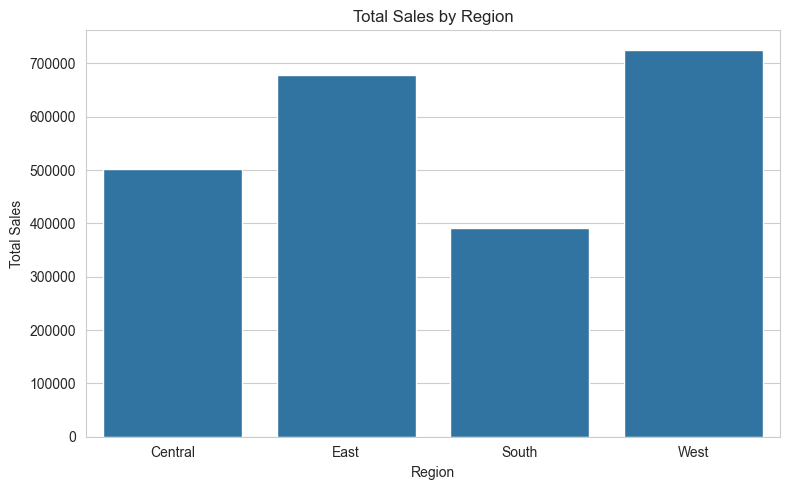

In [40]:
#Sales by region
plt.figure(figsize=(8,5))

sns.barplot(
    x="region",
    y="total_sales",
    data=regional_sales
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.savefig("../images/sales_by_region.png")

plt.show()

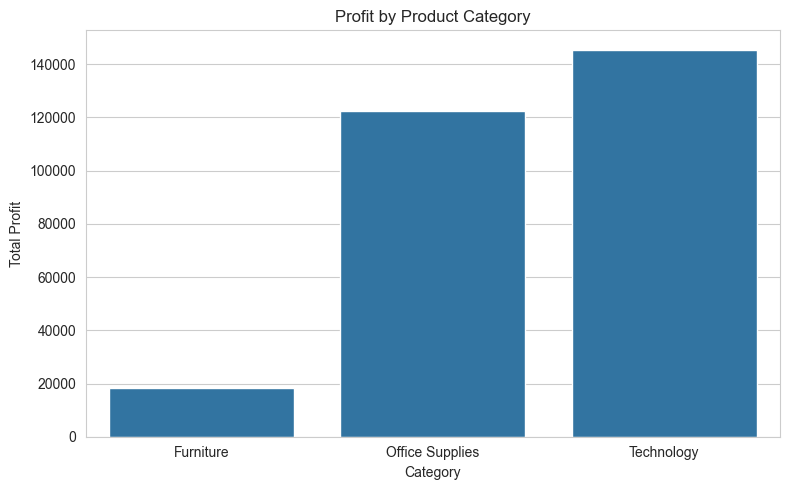

In [41]:
#Profit by category
category_performance = pd.read_sql("""
SELECT category,
       SUM(sales) AS total_sales,
       SUM(profit) AS total_profit
FROM sales
GROUP BY category
""", conn)#reruns the query and stores the result in the category_performance

plt.figure(figsize=(8,5))

sns.barplot(
    x="category",
    y="total_profit",
    data=category_performance
)

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.savefig("../images/profit_by_category.png")

plt.show()

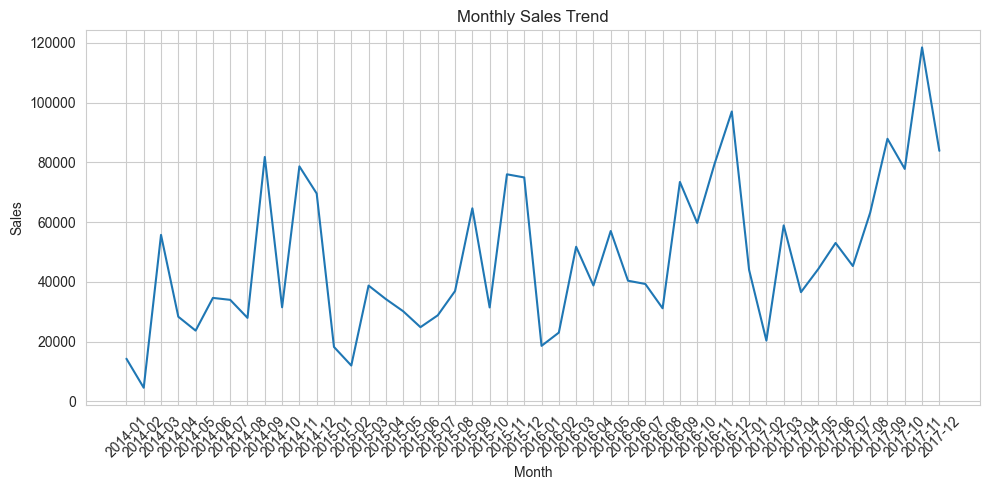

In [44]:
#monthly sales trends
monthly_sales = pd.read_sql("""
SELECT strftime('%Y-%m', order_date) AS month,
       SUM(sales) AS monthly_sales
FROM sales
GROUP BY month
ORDER BY month
""", conn)#reruns the query and stores the result in the monthly_sales

plt.figure(figsize=(10,5))

sns.lineplot(
    x="month",
    y="monthly_sales",
    data=monthly_sales
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("../images/monthly_sales_trend.png")

plt.show()

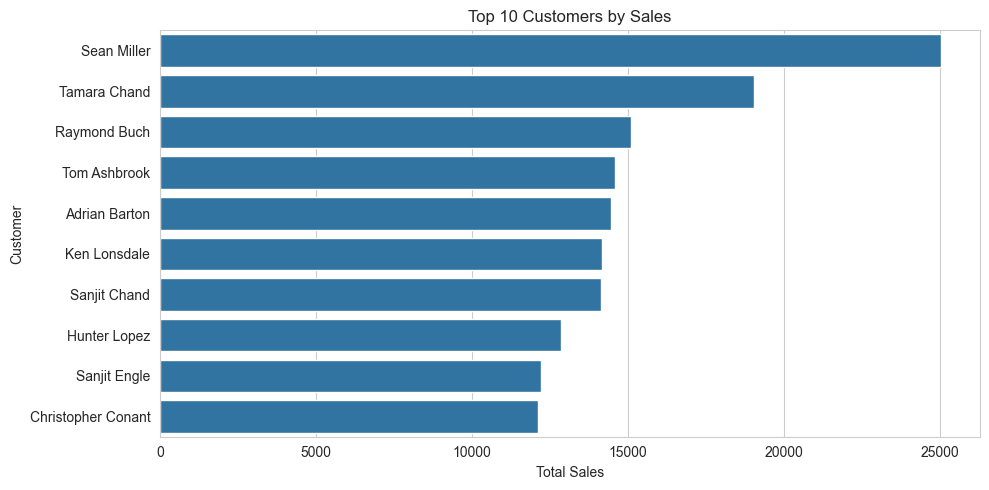

In [45]:
#top customers
top_customers = pd.read_sql("""
SELECT customer_name,
       SUM(sales) AS total_sales
FROM sales
GROUP BY customer_name
ORDER BY total_sales DESC
LIMIT 10
""", conn)#reruns the query and stores the result in the top_customers

plt.figure(figsize=(10,5))

sns.barplot(
    x="total_sales",
    y="customer_name",
    data=top_customers
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer")

plt.tight_layout()
plt.savefig("../images/top_customers.png")

plt.show()

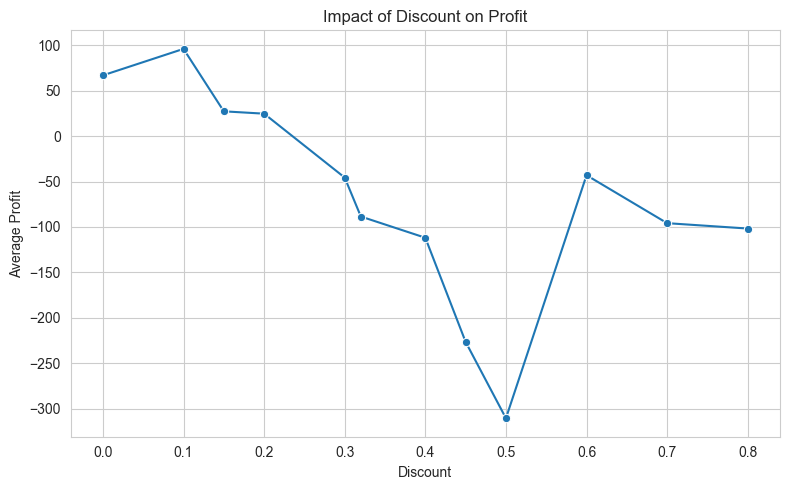

In [46]:
#discount profit relationship
discount_profit = pd.read_sql("""
SELECT discount,
       AVG(profit) AS avg_profit
FROM sales
GROUP BY discount
ORDER BY discount
""", conn)##reruns the query and stores the result in the discount_profit

plt.figure(figsize=(8,5))

sns.lineplot(
    x="discount",
    y="avg_profit",
    data=discount_profit,
    marker="o"
)

plt.title("Impact of Discount on Profit")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.tight_layout()
plt.savefig("../images/discount_vs_profit.png")

plt.show()